# SerafinSignal ##demo name
## Restaurant Complaint Theme Discovery Across Restaurants in Turkey

**Student:** Tawshif Al Mehrab  
**Course:** IAT 461  
**Term:** Summer 2026

---

## 1. Project Overview

This project analyzes restaurant reviews from a fictional restaurant review platform operating in Turkey. The stakeholder is the Director of Marketing and Outreach, who wants to understand the recurring reasons customers are dissatisfied rather than relying only on raw reviews also star ratings.

The main question is:

**What complaint themes appear across restaurant reviews and which themes recur across multiple restaurants rather than being specific to one restaurant?**

The project uses unsupervised text analysis because the dataset does not contain predefined complaint-theme labels. The goal is to discover meaningful and actionable complaint patterns from the review text.

***CONTENTS***
1. Executive Overview / Client Problem
2. Dataset Loading & Documentation
3. Data Quality & Cleaning
4. Exploratory Data Analysis
5. Problem Formulation & Technique Selection
6. Text Preprocessing
7. Baseline Complaint Theme Model
8. Semantic Complaint Theme Model
9. Model Evaluation & Selection
10. Final Complaint Themes
11. Cross-Restaurant Analysis
12. Stakeholder Findings
13. Assumptions Log
14. Limitations
15. Executive Summary
16. Presentation / App Links

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
pd.set_option("display.max_colwidth", 150)
DATA_PATH = "reviews.csv"
df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (1100, 6)


,business_name,author_name,text,photo,rating,rating_category
0,Haci'nin Yeri - Yigit Lokantasi,Gulsum Akar,We went to Marmaris with my wife for a holiday. We chose this restaurant as a place for dinner based on the reviews and because we wanted juicy fo...,dataset/taste/hacinin_yeri_gulsum_akar.png,5,taste
1,Haci'nin Yeri - Yigit Lokantasi,Oguzhan Cetin,During my holiday in Marmaris we ate here to fit the food. It's really good that the food is cheap and nice. Eating as much bread as you want is a...,dataset/menu/hacinin_yeri_oguzhan_cetin.png,4,menu
2,Haci'nin Yeri - Yigit Lokantasi,Yasin Kuyu,Prices are very affordable. The menu in the photo cost 108 liras. You have to wait 10-15 minutes for food. Staff is annoying. Well it tastes good....,dataset/outdoor_atmosphere/hacinin_yeri_yasin_kuyu.png,3,outdoor_atmosphere
3,Haci'nin Yeri - Yigit Lokantasi,Orhan Kapu,Turkey's cheapest artisan restaurant and its food is delicious!,dataset/indoor_atmosphere/hacinin_yeri_orhan_kapu.png,5,indoor_atmosphere
4,Haci'nin Yeri - Yigit Lokantasi,Ozgur Sati,I don't know what you will look for in terms of price performance point; taste; but yigit restaurant writes a big plus for those who come to work ...,dataset/menu/hacinin_yeri_ozgur_sati.png,3,menu


In [4]:
print("Columns:")
print(df.columns.tolist())
print("\nData types:")
display(df.dtypes.to_frame("data_type"))
print("\nMissing values:")
display(df.isna().sum().to_frame("missing_values"))
print("\nUnique restaurants:")
print(df["business_name"].nunique())
print("\nExact duplicate rows:")
print(df.duplicated().sum())
print("\nDuplicate review texts:")
print(df.duplicated(subset=["text"]).sum())

Columns:
['business_name', 'author_name', 'text', 'photo', 'rating', 'rating_category']

Data types:


,data_type
business_name,str
author_name,str
text,str
photo,str
rating,int64
rating_category,str



Missing values:


,missing_values
business_name,0
author_name,0
text,0
photo,0
rating,0
rating_category,0



Unique restaurants:
100

Exact duplicate rows:
0

Duplicate review texts:
12


In [5]:
print("Rating distribution:")
display(df["rating"].value_counts().sort_index().to_frame("reviews"))
print("\nRating category distribution:")
display(df["rating_category"].value_counts().to_frame("reviews"))
print("\nReviews per restaurant:")
display(df["business_name"] .value_counts().describe())

Rating distribution:


,reviews
rating,
1,80
2,72
3,172
4,316
5,460



Rating category distribution:


,reviews
rating_category,
taste,330
indoor_atmosphere,288
outdoor_atmosphere,286
menu,196



Reviews per restaurant:


count    100.0
mean      11.0
std        0.0
min       11.0
25%       11.0
50%       11.0
75%       11.0
max       11.0
Name: count, dtype: float64

In [6]:
df["review_word_count"] = ( df["text"].astype(str).str.split().str.len())
display(df["review_word_count"].describe())

count    1100.000000
mean       20.051818
std        12.977619
min         1.000000
25%        11.000000
50%        19.000000
75%        27.000000
max       179.000000
Name: review_word_count, dtype: float64

In [7]:
rating_groups = pd.cut(df["rating"],bins=[0, 2, 3, 5],labels=["NEGATIVE (1-2)","MIXED (3)","POSITIVE (4-5)"])
df["rating_group"] = rating_groups
display(df["rating_group"].value_counts().to_frame("reviews"))

,reviews
rating_group,
POSITIVE (4-5),776
MIXED (3),172
NEGATIVE (1-2),152


All reviews are included in the analysis based on client clarification. Ratings will not be used to filter the corpus before clustering. Instead, ratings will be used afterward to understand whether discovered themes are associated with positive, negative, or mixed experiences.

## 2. Exploratory Data Analysis

This section examines the overall structure of the review dataset before applying unsupervised learning and the goal is to understand rating patterns, review length, restaurant level differences also existing review categories.

All reviews are retained for theme discovery-i.e.ratings are used afterward to help interpret whether a discovered theme is associated with positive, mixed, or negative experiences.

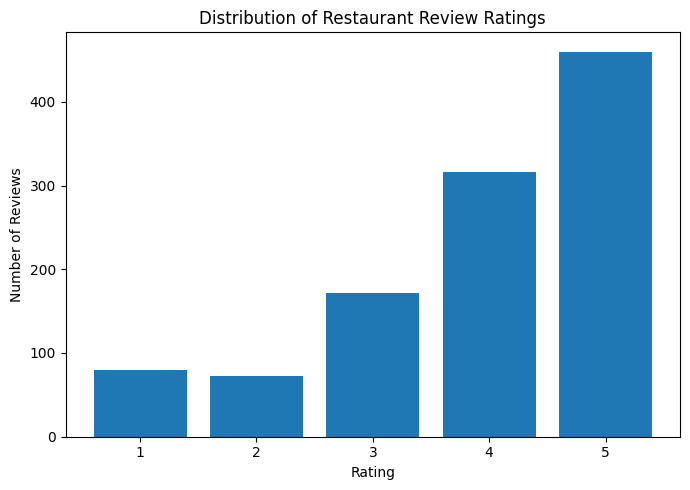

In [8]:
rating_counts = (df["rating"].value_counts().sort_index())
plt.figure(figsize=(7, 5))
plt.bar(rating_counts.index.astype(str),rating_counts.values)
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Restaurant Review Ratings")
plt.tight_layout()
plt.show()

In [9]:
review_length_by_rating = (df.groupby("rating")["review_word_count"].agg(["mean", "median", "count"]) .round(2))
display(review_length_by_rating)

,mean,median,count
rating,,,
1,21.76,20.0,80
2,23.36,22.0,72
3,20.14,20.0,172
4,20.12,19.0,316
5,19.16,17.0,460


<Figure size 800x500 with 0 Axes>

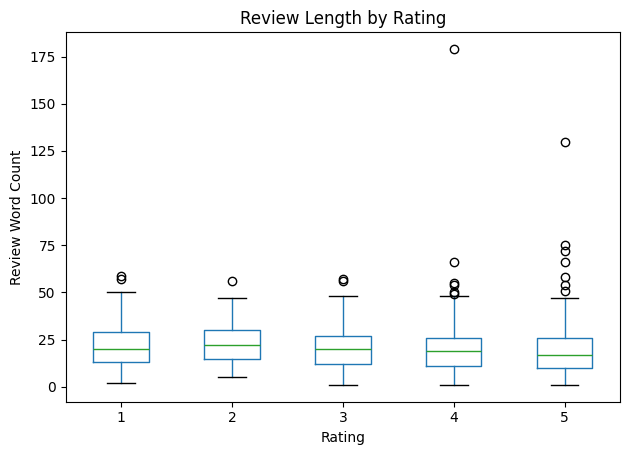

In [10]:
plt.figure(figsize=(8, 5))
df.boxplot(column="review_word_count",by="rating",grid=False)
plt.xlabel("Rating")
plt.ylabel("Review Word Count")
plt.title("Review Length by Rating")
plt.suptitle("")
plt.tight_layout()
plt.show()

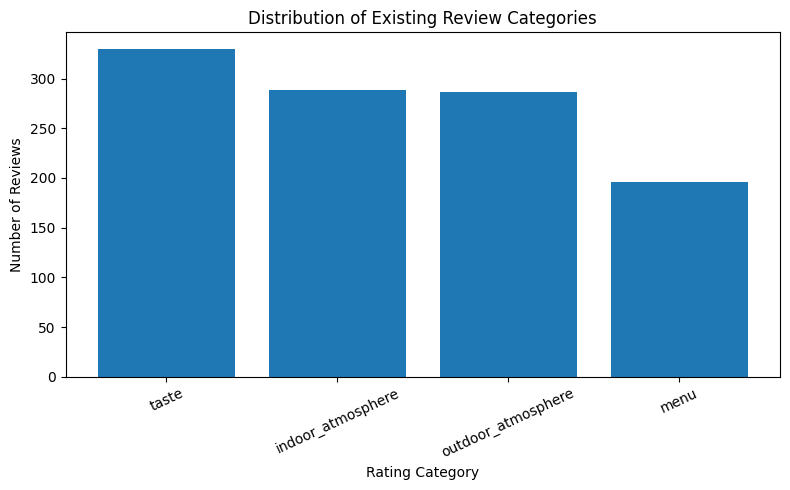

In [11]:
category_counts = (df["rating_category"].value_counts())
plt.figure(figsize=(8, 5))
plt.bar( category_counts.index,category_counts.values)
plt.xlabel("Rating Category")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Existing Review Categories")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

In [12]:
category_rating_summary = (df.groupby("rating_category")["rating"].agg(["mean", "median", "count"]).sort_values("mean").round(2))
display(category_rating_summary)

,mean,median,count
rating_category,,,
menu,3.69,4.0,196
taste,3.94,4.0,330
indoor_atmosphere,3.96,4.0,288
outdoor_atmosphere,3.99,4.0,286


In [13]:
restaurant_summary = (df.groupby("business_name").agg(reviews=("text", "count"),average_rating=("rating", "mean"),median_rating=("rating", "median")).sort_values("average_rating"))
display(restaurant_summary.head(10))
display(restaurant_summary.tail(10))

,reviews,average_rating,median_rating
business_name,,,
Medeniyetler Sofrasi,11,3.000000,3.0
Popeyes,11,3.000000,3.0
Salih Usta,11,3.000000,3.0
Baskent Aspava,11,3.090909,3.0
Mado,11,3.181818,3.0
Tavuk Dunyasi,11,3.272727,4.0
KFC,11,3.272727,4.0
Diyarbakir Ocakbasi Palace,11,3.272727,4.0
Cemo Etliekmek,11,3.363636,4.0


,reviews,average_rating,median_rating
business_name,,,
Hasan Usta,11,4.363636,5.0
Pukka Marmaris,11,4.363636,4.0
Cici Tantuni,11,4.363636,4.0
Kumsal Lokantasi,11,4.363636,4.0
Bunbun Kas,11,4.454545,5.0
Churchill Bistro,11,4.454545,5.0
Haci'nin Yeri - Yigit Lokantasi,11,4.454545,5.0
Antakya Mutfagi,11,4.454545,5.0
Yesemek,11,4.454545,5.0


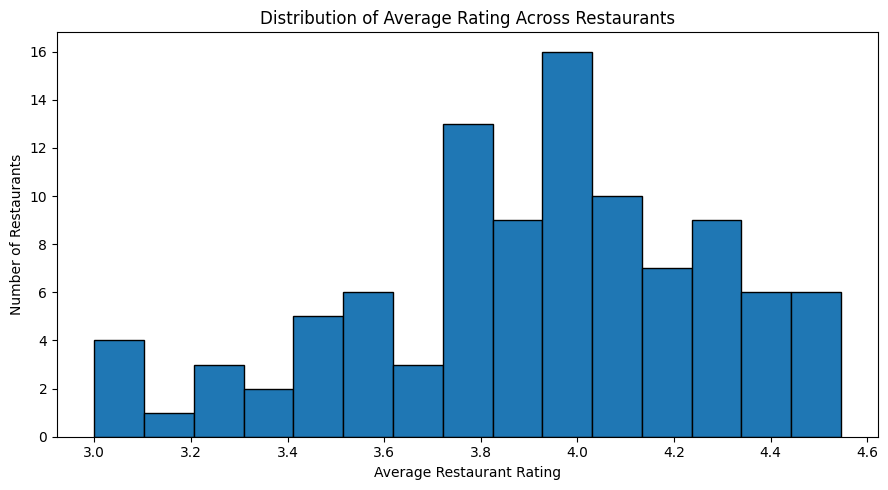

In [14]:
plt.figure(figsize=(9, 5))
plt.hist( restaurant_summary["average_rating"],bins=15,edgecolor="black")
plt.xlabel("Average Restaurant Rating")
plt.ylabel("Number of Restaurants")
plt.title("Distribution of Average Rating Across Restaurants")
plt.tight_layout()
plt.show()

In [15]:
duplicate_texts = df[df.duplicated(subset=["text"],keep=False)
].sort_values("text")
print("Rows involved in duplicate review texts:", len(duplicate_texts))
display(duplicate_texts[["business_name", "text", "rating","rating_category"]])

Rows involved in duplicate review texts: 19


,business_name,text,rating,rating_category
162,Tatbak,Delicious!,4,taste
321,Sardalye,Delicious!,5,indoor_atmosphere
962,Kadineli,Delicious!,5,outdoor_atmosphere
942,Fikret Balik Restaurant,Expensive place.,1,menu
1050,Lipa,Expensive place.,3,menu
500,Kebabci Halil Usta,Expensive.,3,outdoor_atmosphere
619,Midyeci Ahmet,Expensive.,3,menu
973,Anzelha,Expensive.,3,indoor_atmosphere
72,Gold Semaver,Great.,4,outdoor_atmosphere
228,Salacak,Great.,4,menu


## 3. Data Cleaning Text Preparation

The exploratory analysis showed that the dataset contains no missing values and no fully duplicated rows. A small number of review texts repeat across different restaurants, but these are mostly short and generic expressions 

In [16]:
model_df = df[["business_name","text","rating","rating_category","rating_group", "review_word_count"]].copy()
model_df = model_df.rename( columns={"text": "text_original"})
print("Modeling dataset shape:", model_df.shape)
display(model_df.head())

Modeling dataset shape: (1100, 6)


,business_name,text_original,rating,rating_category,rating_group,review_word_count
0,Haci'nin Yeri - Yigit Lokantasi,We went to Marmaris with my wife for a holiday. We chose this restaurant as a place for dinner based on the reviews and because we wanted juicy fo...,5,taste,POSITIVE (4-5),130
1,Haci'nin Yeri - Yigit Lokantasi,During my holiday in Marmaris we ate here to fit the food. It's really good that the food is cheap and nice. Eating as much bread as you want is a...,4,menu,POSITIVE (4-5),179
2,Haci'nin Yeri - Yigit Lokantasi,Prices are very affordable. The menu in the photo cost 108 liras. You have to wait 10-15 minutes for food. Staff is annoying. Well it tastes good....,3,outdoor_atmosphere,MIXED (3),31
3,Haci'nin Yeri - Yigit Lokantasi,Turkey's cheapest artisan restaurant and its food is delicious!,5,indoor_atmosphere,POSITIVE (4-5),9
4,Haci'nin Yeri - Yigit Lokantasi,I don't know what you will look for in terms of price performance point; taste; but yigit restaurant writes a big plus for those who come to work ...,3,menu,MIXED (3),31


In [17]:
import re
def clean_review_text(text):
    text = str(text)
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"\s+([,.!?;:])",r"\1",text)
    return text.strip()
model_df["text_clean"] = ( model_df["text_original"].apply(clean_review_text))
display(model_df[["text_original","text_clean"]].head(10))

,text_original,text_clean
0,We went to Marmaris with my wife for a holiday. We chose this restaurant as a place for dinner based on the reviews and because we wanted juicy fo...,We went to Marmaris with my wife for a holiday. We chose this restaurant as a place for dinner based on the reviews and because we wanted juicy fo...
1,During my holiday in Marmaris we ate here to fit the food. It's really good that the food is cheap and nice. Eating as much bread as you want is a...,During my holiday in Marmaris we ate here to fit the food. It's really good that the food is cheap and nice. Eating as much bread as you want is a...
2,Prices are very affordable. The menu in the photo cost 108 liras. You have to wait 10-15 minutes for food. Staff is annoying. Well it tastes good....,Prices are very affordable. The menu in the photo cost 108 liras. You have to wait 10-15 minutes for food. Staff is annoying. Well it tastes good....
3,Turkey's cheapest artisan restaurant and its food is delicious!,Turkey's cheapest artisan restaurant and its food is delicious!
4,I don't know what you will look for in terms of price performance point; taste; but yigit restaurant writes a big plus for those who come to work ...,I don't know what you will look for in terms of price performance point; taste; but yigit restaurant writes a big plus for those who come to work ...
5,Generally good.,Generally good.
6,What you see is 125 TL in total. It's a pretty convenient place. We can say that it is an artisan restaurant; you should not expect a restaurant; ...,What you see is 125 TL in total. It's a pretty convenient place. We can say that it is an artisan restaurant; you should not expect a restaurant; ...
7,Delicious food at rock bottom prices. Friendly staff; Highly recommend,Delicious food at rock bottom prices. Friendly staff; Highly recommend
8,"Every time I go, I still experience the amazement I experienced years ago as if it were the first time. There is no need to explain. Folk hero is ...","Every time I go, I still experience the amazement I experienced years ago as if it were the first time. There is no need to explain. Folk hero is ..."
9,The most f/p of all businesses I've seen.,The most f/p of all businesses I've seen.


3.1 Validate cleaning

In [18]:
print( "Empty cleaned reviews:",(model_df["text_clean"].str.len() == 0).sum())
print("Unique original texts:", model_df["text_original"].nunique())
print("Unique cleaned texts:",model_df["text_clean"].nunique())
print("Average words per review:",round(model_df["review_word_count"].mean(),2))

Empty cleaned reviews: 0
Unique original texts: 1088
Unique cleaned texts: 1088
Average words per review: 20.05


In [19]:
short_reviews = (model_df.sort_values("review_word_count")[["business_name", "text_clean","rating", "rating_category","review_word_count"]].head(20))
display(short_reviews)

,business_name,text_clean,rating,rating_category,review_word_count
534,Kasikla Restaurant,Recommend.,5,outdoor_atmosphere,1
544,Askin Tostevi,Liked.,4,outdoor_atmosphere,1
500,Kebabci Halil Usta,Expensive.,3,outdoor_atmosphere,1
582,Kaliteci,Loved.,5,outdoor_atmosphere,1
424,Bilice,Great.,5,indoor_atmosphere,1
619,Midyeci Ahmet,Expensive.,3,menu,1
72,Gold Semaver,Great.,4,outdoor_atmosphere,1
293,Nazar Cafe,Good.,4,menu,1
962,Kadineli,Delicious!,5,outdoor_atmosphere,1
296,Nazar Cafe,Recommend.,4,indoor_atmosphere,1
